In [1]:
import os
import time
import copy
import gc
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Thư viện PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Dataset

# Kiểm tra xem GPU Kaggle đã bật chưa
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# Đường dẫn dataset (Chạy !ls /kaggle/input/ để đảm bảo đường dẫn đúng)
DATA_DIR = '/kaggle/input/datasets/maysee/mushrooms-classification-common-genuss-images/Mushrooms'

# Thông số huấn luyện
BATCH_SIZE = 32
IMG_SIZE = 224
VAL_SPLIT = 0.2

Đang sử dụng thiết bị: cuda


In [2]:
# 1. Transform cho tập Training (Có Augmentation để chống Overfitting)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),        
    transforms.RandomCrop(IMG_SIZE),      
    transforms.RandomHorizontalFlip(),    
    transforms.RandomRotation(20),        
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Transform cho tập Validation (Không biến dạng ảnh)
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Class Wrapper để ép Transform khác nhau
class DatasetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# 4. Load toàn bộ thư mục
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)
print(f"Đã tìm thấy {NUM_CLASSES} classes: {class_names}")

# 5. Chia Train/Val
train_size = int((1 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size
raw_train_set, raw_val_set = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_dataset = DatasetWrapper(raw_train_set, transform=train_transforms)
val_dataset = DatasetWrapper(raw_val_set, transform=val_transforms)

# 6. Đẩy vào DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Số lượng ảnh Training: {len(train_dataset)} | Validation: {len(val_dataset)}")

Đã tìm thấy 9 classes: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
Số lượng ảnh Training: 5371 | Validation: 1343


In [3]:
from PIL import Image, ImageFile
import os

# Cho phép PIL đọc các ảnh bị truncated
ImageFile.LOAD_TRUNCATED_IMAGES = True

print("Đang tính toán Class Weights...")
train_labels = [label for _, label in raw_train_set]
class_counts = Counter(train_labels)

total_samples = len(train_labels)
class_weights = []
for i in range(NUM_CLASSES):
    weight = total_samples / (NUM_CLASSES * class_counts[i])
    class_weights.append(weight)

# Đẩy vào GPU để chuẩn bị làm Loss function
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("\nTrọng số cho từng class:")
for i, name in enumerate(class_names):
    print(f"- {name}: {class_weights[i]:.2f}")

Đang tính toán Class Weights...

Trọng số cho từng class:
- Agaricus: 2.07
- Amanita: 1.00
- Boletus: 0.70
- Cortinarius: 0.88
- Entoloma: 2.01
- Hygrocybe: 2.27
- Lactarius: 0.48
- Russula: 0.65
- Suillus: 2.46


In [4]:
def build_model(model_name, num_classes, freeze_backbone=True):
    if model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, num_classes))
        
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, num_classes))
        
    elif model_name == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters(): param.requires_grad = False
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_ftrs, num_classes))
    else:
        raise ValueError("Tên model sai!")
        
    return model.to(device)

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' - ')
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}', end=' | ')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print() # Xuống dòng cho epoch mới

    print(f'\nBest Val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [6]:
models_to_test = ["mobilenet_v2", "efficientnet_b0", "vit_b_16"]
experiment_results = {}
EPOCHS_PER_MODEL = 15 # Nên chạy 15 epoch cho nhanh, độ chính xác vẫn rất cao

for model_name in models_to_test:
    print(f"\n================ STARTING: {model_name.upper()} ================")
    
    # 1. Build Model
    model = build_model(model_name, NUM_CLASSES, freeze_backbone=True)
    
    # 2. Cấu hình Loss (có Weight) và Optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    
    # 3. Train
    trained_model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=EPOCHS_PER_MODEL)
    
    # 4. Lưu lại
    best_val_acc = max(history['val_acc'])
    weight_path = f'{model_name}_best.pth'
    torch.save(trained_model.state_dict(), weight_path)
    
    experiment_results[model_name] = {
        'history': history,
        'best_val_acc': best_val_acc,
        'weight_path': weight_path
    }
    
    # 5. Dọn dẹp VRAM ngay lập tức để không chết RAM
    del trained_model, model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()


================ STARTING: MOBILENET_V2 ================
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


Epoch 1/15 - TRAIN Loss: 1.5645 Acc: 0.4496 | VAL Loss: 1.2267 Acc: 0.5272 | 
Epoch 2/15 - TRAIN Loss: 1.1515 Acc: 0.5934 | VAL Loss: 1.0840 Acc: 0.5614 | 
Epoch 3/15 - TRAIN Loss: 1.0577 Acc: 0.6196 | VAL Loss: 0.9269 Acc: 0.6724 | 
Epoch 4/15 - TRAIN Loss: 1.0302 Acc: 0.6282 | VAL Loss: 0.9383 Acc: 0.6359 | 
Epoch 5/15 - TRAIN Loss: 0.9976 Acc: 0.6252 | VAL Loss: 0.8908 Acc: 0.6605 | 
Epoch 6/15 - TRAIN Loss: 0.9578 Acc: 0.6399 | VAL Loss: 0.8399 Acc: 0.6902 | 
Epoch 7/15 - TRAIN Loss: 0.9698 Acc: 0.6444 | VAL Loss: 0.8614 Acc: 0.6880 | 
Epoch 8/15 - TRAIN Loss: 0.9398 Acc: 0.6490 | VAL Loss: 0.8797 Acc: 0.6582 | 
Epoch 9/15 - TRAIN Loss: 0.9495 Acc: 0.6483 | VAL Loss: 0.8505 Acc: 0.6865 | 
Epoch 10/15 - TRAIN Loss: 0.8722 Acc: 0.6654 | VAL Loss: 0.8098 Acc: 0.6992 | 
Epoch 11/15 - TRAIN Loss: 0.8767 Acc: 0.6727 | VAL Loss: 0.8215 Acc: 0.6895 | 
Epoch 12/15 - TRAIN Loss: 0.8664 Acc: 0.6751 | VAL Loss: 0.7936 Acc: 0.7096 | 
Epoch 13/15 - TRAIN Loss: 0.8704 Acc: 0.6690 | VAL Loss: 0.80

100%|██████████| 20.5M/20.5M [00:00<00:00, 129MB/s] 


Epoch 1/15 - TRAIN Loss: 1.6144 Acc: 0.4582 | VAL Loss: 1.2636 Acc: 0.5547 | 
Epoch 2/15 - TRAIN Loss: 1.2233 Acc: 0.5800 | VAL Loss: 1.0941 Acc: 0.6076 | 
Epoch 3/15 - TRAIN Loss: 1.1082 Acc: 0.6051 | VAL Loss: 1.0334 Acc: 0.6463 | 
Epoch 4/15 - TRAIN Loss: 1.0662 Acc: 0.6159 | VAL Loss: 0.9745 Acc: 0.6404 | 
Epoch 5/15 - TRAIN Loss: 1.0288 Acc: 0.6198 | VAL Loss: 0.9444 Acc: 0.6396 | 
Epoch 6/15 - TRAIN Loss: 0.9915 Acc: 0.6336 | VAL Loss: 0.9062 Acc: 0.6530 | 
Epoch 7/15 - TRAIN Loss: 0.9670 Acc: 0.6397 | VAL Loss: 0.8970 Acc: 0.6560 | 
Epoch 8/15 - TRAIN Loss: 0.9534 Acc: 0.6440 | VAL Loss: 0.8770 Acc: 0.6709 | 
Epoch 9/15 - TRAIN Loss: 0.9561 Acc: 0.6461 | VAL Loss: 0.8682 Acc: 0.6724 | 
Epoch 10/15 - TRAIN Loss: 0.9154 Acc: 0.6526 | VAL Loss: 0.8630 Acc: 0.6612 | 
Epoch 11/15 - TRAIN Loss: 0.9323 Acc: 0.6516 | VAL Loss: 0.8512 Acc: 0.6679 | 
Epoch 12/15 - TRAIN Loss: 0.9106 Acc: 0.6494 | VAL Loss: 0.8477 Acc: 0.6687 | 
Epoch 13/15 - TRAIN Loss: 0.9099 Acc: 0.6602 | VAL Loss: 0.84

100%|██████████| 330M/330M [00:02<00:00, 146MB/s]


Epoch 1/15 - TRAIN Loss: 1.4020 Acc: 0.5176 | VAL Loss: 1.0816 Acc: 0.6404 | 
Epoch 2/15 - TRAIN Loss: 0.9904 Acc: 0.6578 | VAL Loss: 0.9056 Acc: 0.7007 | 
Epoch 3/15 - TRAIN Loss: 0.8624 Acc: 0.7047 | VAL Loss: 0.8367 Acc: 0.7334 | 
Epoch 4/15 - TRAIN Loss: 0.7991 Acc: 0.7243 | VAL Loss: 0.7626 Acc: 0.7573 | 
Epoch 5/15 - TRAIN Loss: 0.7440 Acc: 0.7425 | VAL Loss: 0.7165 Acc: 0.7520 | 
Epoch 6/15 - TRAIN Loss: 0.7099 Acc: 0.7524 | VAL Loss: 0.6884 Acc: 0.7632 | 
Epoch 7/15 - TRAIN Loss: 0.6803 Acc: 0.7583 | VAL Loss: 0.6706 Acc: 0.7722 | 
Epoch 8/15 - TRAIN Loss: 0.6683 Acc: 0.7632 | VAL Loss: 0.6661 Acc: 0.7587 | 
Epoch 9/15 - TRAIN Loss: 0.6496 Acc: 0.7676 | VAL Loss: 0.6376 Acc: 0.7863 | 
Epoch 10/15 - TRAIN Loss: 0.6361 Acc: 0.7766 | VAL Loss: 0.6162 Acc: 0.7863 | 
Epoch 11/15 - TRAIN Loss: 0.6323 Acc: 0.7755 | VAL Loss: 0.6098 Acc: 0.7848 | 
Epoch 12/15 - TRAIN Loss: 0.6170 Acc: 0.7771 | VAL Loss: 0.6063 Acc: 0.7848 | 
Epoch 13/15 - TRAIN Loss: 0.6041 Acc: 0.7749 | VAL Loss: 0.59

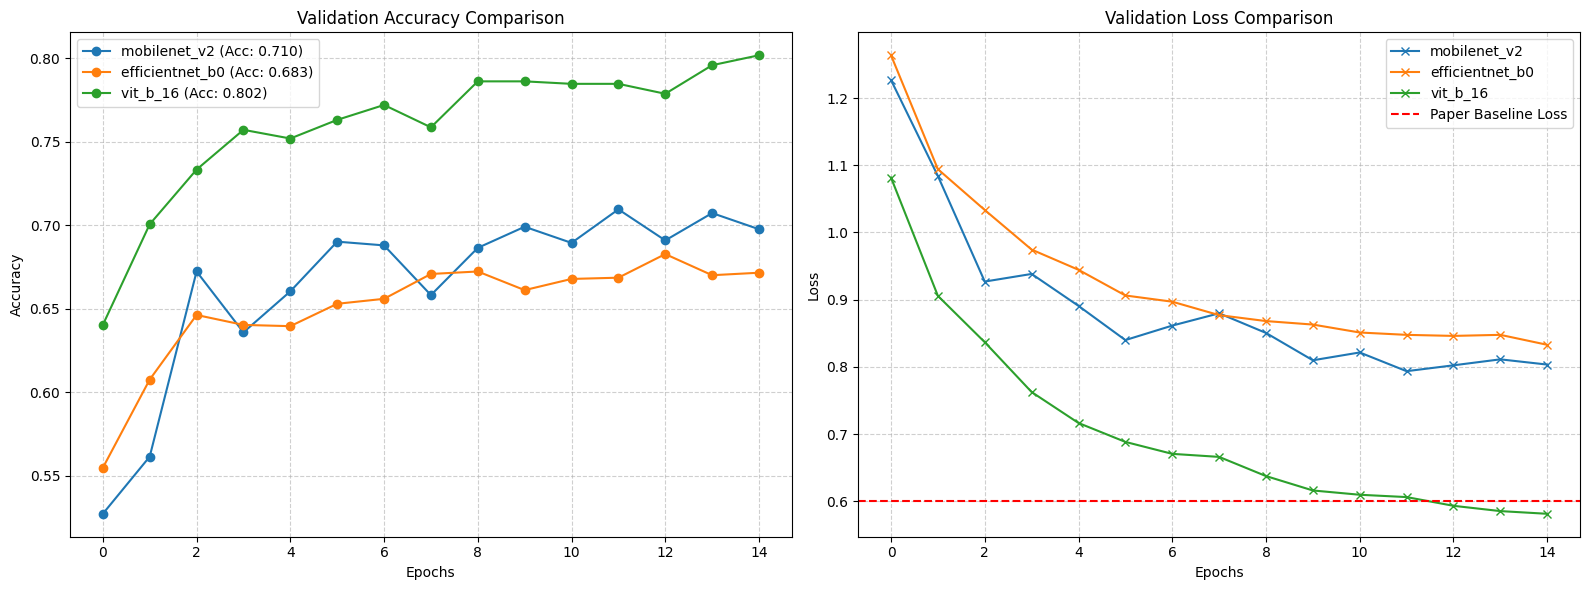


🎉 MÔ HÌNH TỐT NHẤT: VIT_B_16 (Khôi phục vào biến 'best_model')


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [7]:
plt.figure(figsize=(16, 6))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
for model_name, data in experiment_results.items():
    plt.plot(data['history']['val_acc'], label=f"{model_name} (Acc: {data['best_val_acc']:.3f})", marker='o')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Biểu đồ Loss
plt.subplot(1, 2, 2)
for model_name, data in experiment_results.items():
    plt.plot(data['history']['val_loss'], label=model_name, marker='x')
plt.axhline(y=0.6, color='r', linestyle='--', label='Paper Baseline Loss') # Loss của paper gốc
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# --- CHỌN MÔ HÌNH XUẤT SẮC NHẤT ĐỂ CHUẨN BỊ LÀM BƯỚC SAU ---
best_model_name = max(experiment_results, key=lambda k: experiment_results[k]['best_val_acc'])
print(f"\n🎉 MÔ HÌNH TỐT NHẤT: {best_model_name.upper()} (Khôi phục vào biến 'best_model')")

# Load model tốt nhất ra để sẵn sàng làm Inference / Confusion Matrix
best_model = build_model(best_model_name, NUM_CLASSES, freeze_backbone=True)
best_model.load_state_dict(torch.load(experiment_results[best_model_name]['weight_path']))
best_model.eval()

Đang đánh giá mô hình ViT tốt nhất trên tập Validation...

BÁO CÁO ĐÁNH GIÁ CHUYÊN SÂU (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

    Agaricus     0.6250    0.7692    0.6897        65
     Amanita     0.8963    0.7756    0.8316       156
     Boletus     0.9204    0.9541    0.9369       218
 Cortinarius     0.7899    0.6987    0.7415       156
    Entoloma     0.5743    0.8657    0.6905        67
   Hygrocybe     0.8095    0.9623    0.8793        53
   Lactarius     0.8316    0.7508    0.7891       329
     Russula     0.8143    0.7403    0.7755       231
     Suillus     0.6667    0.9118    0.7702        68

    accuracy                         0.8019      1343
   macro avg     0.7698    0.8254    0.7894      1343
weighted avg     0.8136    0.8019    0.8030      1343



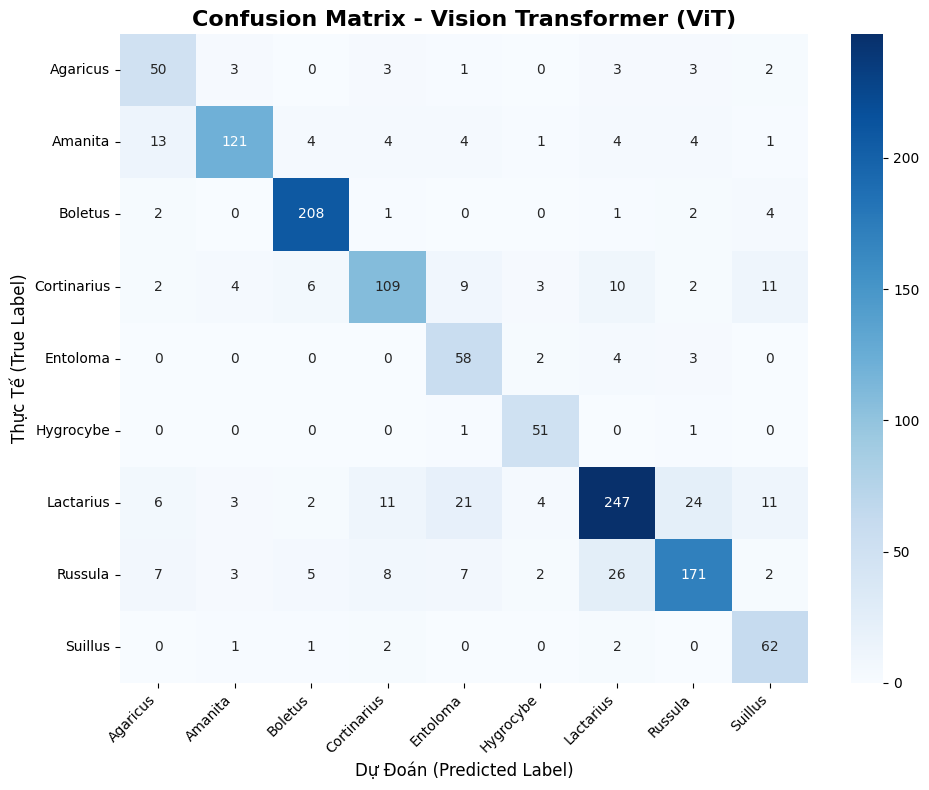

In [8]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("Đang đánh giá mô hình ViT tốt nhất trên tập Validation...")

# 1. Chạy mô hình trên toàn bộ tập Validation để lấy dự đoán
best_model.eval() # Bật chế độ suy luận
y_true = []
y_pred = []

with torch.no_grad(): # Tắt tính toán gradient để tiết kiệm RAM và tăng tốc
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 2. In Báo Cáo Phân Loại (Classification Report)
print("\n" + "="*50)
print("BÁO CÁO ĐÁNH GIÁ CHUYÊN SÂU (CLASSIFICATION REPORT)")
print("="*50)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# 3. Vẽ Ma Trận Nhầm Lẫn (Confusion Matrix)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)

# Vẽ Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Vision Transformer (ViT)', fontsize=16, fontweight='bold')
plt.xlabel('Dự Đoán (Predicted Label)', fontsize=12)
plt.ylabel('Thực Tế (True Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim

print("BẮT ĐẦU FINE-TUNING CỰC HẠN CHO ViT (UNFREEZE BACKBONE)")

# 1. Khởi tạo lại ViT nhưng lần này UNFREEZE (Mở khóa toàn bộ trọng số)
# Lưu ý: Hàm build_model đã được định nghĩa ở các cell trước
model_ft = build_model("vit_b_16", NUM_CLASSES, freeze_backbone=False)

# 2. Load trọng số tốt nhất mà bạn vừa đạt được (~80.8%)
# Nếu bạn lưu file ở tên khác, hãy sửa lại đường dẫn này nhé
best_weight_path = "vit_b_16_best.pth" 
model_ft.load_state_dict(torch.load(best_weight_path))
model_ft = model_ft.to(device)

# 3. Cấu hình Optimizer siêu nhỏ (Để không phá hỏng weights cũ)
# Learning rate = 1e-5 (Rất nhỏ so với 1e-3 lúc trước)
# Thêm weight_decay để L2 Regularization, chống Overfitting mạnh hơn
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-5, weight_decay=1e-4)

# Dùng CosineAnnealingLR: Learning rate sẽ lượn sóng từ từ thay vì giảm gắt
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=15)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# 4. Thiết lập Gradient Accumulation
accumulation_steps = 4  # Tích lũy 4 batch 32 -> tương đương batch size 128

# 5. Viết lại hàm Training có Gradient Accumulation
def train_finetune(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # Lấy lại best acc cũ để chỉ lưu khi vượt qua mức 80.8%
    best_acc = 0.808 
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' - ')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            
            # Khởi tạo lại gradient đầu mỗi pha
            optimizer.zero_grad() 

            for i, (inputs, labels) in enumerate(dataloader):
                inputs, labels = inputs.to(device), labels.to(device)

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    
                    # Tính Loss và chia cho số bước tích lũy
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss = loss / accumulation_steps # Normalize loss
                        loss.backward()
                        
                        # Cập nhật weights mỗi khi đủ số bước tích lũy
                        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
                            optimizer.step()
                            optimizer.zero_grad() # Xóa gradient cho chu kỳ sau

                # Nhân lại loss với accumulation_steps để hiển thị cho đúng
                running_loss += (loss.item() * accumulation_steps if phase == 'train' else loss.item()) * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}', end=' | ')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step() # Cập nhật Learning rate

                # Lưu Model nếu Acc cao hơn
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print("NEW BEST!", end="")
        print() 

    print(f'\nFine-tuning hoàn tất. Đỉnh cao mới: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    # Lưu ra một file mới để phân biệt
    torch.save(model.state_dict(), 'vit_b_16_finetuned_best.pth') 
    return model, history

# BẮT ĐẦU CHẠY
model_ft, hist_ft = train_finetune(model_ft, criterion, optimizer_ft, scheduler_ft, num_epochs=15)

BẮT ĐẦU FINE-TUNING CỰC HẠN CHO ViT (UNFREEZE BACKBONE)
Epoch 1/15 - TRAIN Loss: 0.5195 Acc: 0.8097 | VAL Loss: 0.4503 Acc: 0.8295 | NEW BEST!
Epoch 2/15 - TRAIN Loss: 0.3664 Acc: 0.8585 | VAL Loss: 0.4125 Acc: 0.8548 | NEW BEST!
Epoch 3/15 - TRAIN Loss: 0.2846 Acc: 0.8853 | VAL Loss: 0.3601 Acc: 0.8734 | NEW BEST!
Epoch 4/15 - TRAIN Loss: 0.2222 Acc: 0.9140 | VAL Loss: 0.3456 Acc: 0.8667 | 
Epoch 5/15 - TRAIN Loss: 0.1878 Acc: 0.9209 | VAL Loss: 0.3418 Acc: 0.8786 | NEW BEST!
Epoch 6/15 - TRAIN Loss: 0.1587 Acc: 0.9341 | VAL Loss: 0.3345 Acc: 0.8838 | NEW BEST!
Epoch 7/15 - TRAIN Loss: 0.1265 Acc: 0.9488 | VAL Loss: 0.3189 Acc: 0.8898 | NEW BEST!
Epoch 8/15 - TRAIN Loss: 0.1130 Acc: 0.9549 | VAL Loss: 0.3265 Acc: 0.8838 | 
Epoch 9/15 - TRAIN Loss: 0.1031 Acc: 0.9570 | VAL Loss: 0.3021 Acc: 0.8905 | NEW BEST!
Epoch 10/15 - TRAIN Loss: 0.0878 Acc: 0.9629 | VAL Loss: 0.3131 Acc: 0.8965 | NEW BEST!
Epoch 11/15 - TRAIN Loss: 0.0786 Acc: 0.9680 | VAL Loss: 0.3105 Acc: 0.8958 | 
Epoch 12/15 

Đang nạp Mô hình Vô địch (ViT Fine-tuned) để đánh giá chuyên sâu...
Đang chạy mô hình qua toàn bộ tập Validation (Vui lòng đợi vài giây)...

 BÁO CÁO ĐÁNH GIÁ CHUYÊN SÂU (CLASSIFICATION REPORT) 📊
              precision    recall  f1-score   support

    Agaricus     0.8194    0.9077    0.8613        65
     Amanita     0.9855    0.8718    0.9252       156
     Boletus     0.9630    0.9541    0.9585       218
 Cortinarius     0.8562    0.8782    0.8671       156
    Entoloma     0.7625    0.9104    0.8299        67
   Hygrocybe     0.9615    0.9434    0.9524        53
   Lactarius     0.9238    0.8845    0.9037       329
     Russula     0.8577    0.8874    0.8723       231
     Suillus     0.8592    0.8971    0.8777        68

    accuracy                         0.8995      1343
   macro avg     0.8877    0.9039    0.8942      1343
weighted avg     0.9032    0.8995    0.9003      1343



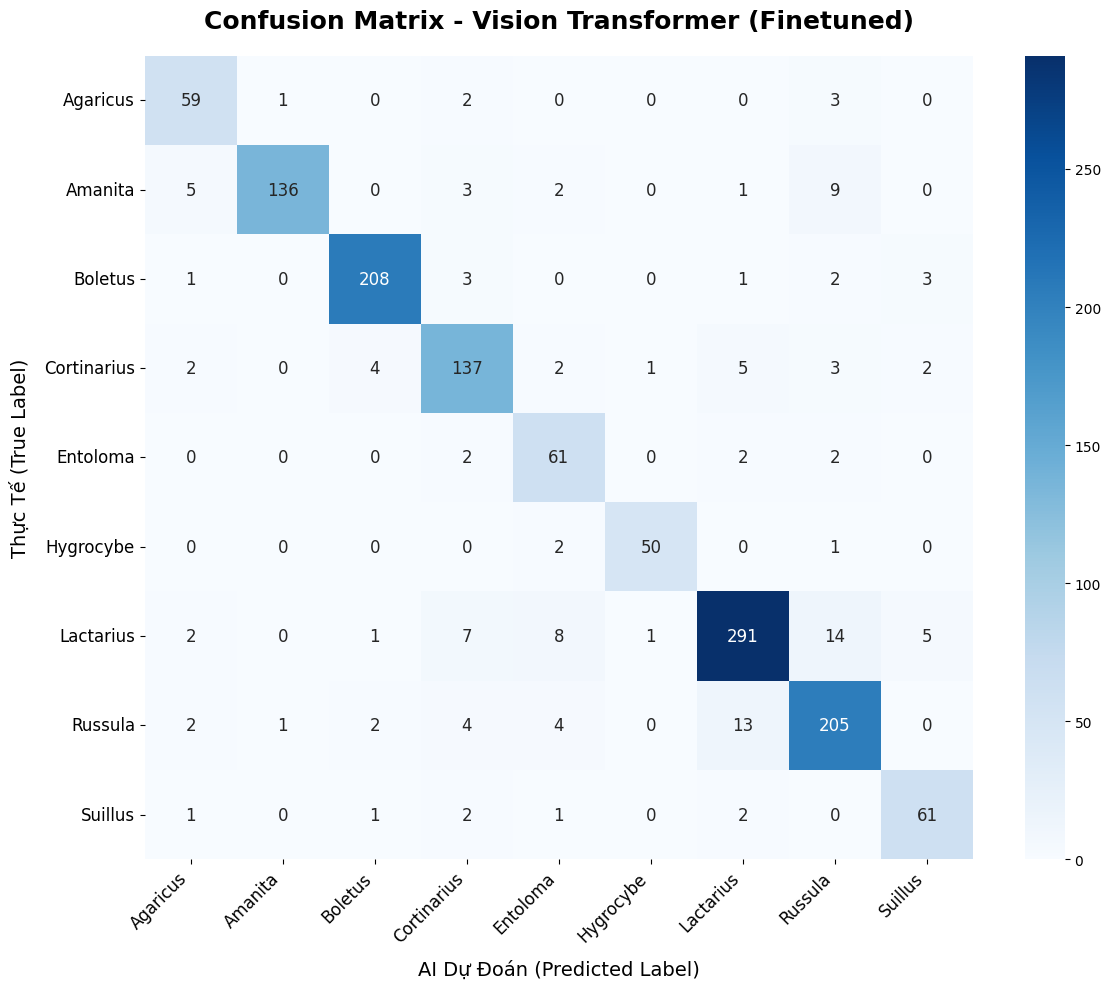

Đã lưu ảnh Confusion Matrix thành công (confusion_matrix_vit.png)!


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Đang nạp Mô hình Vô địch (ViT Fine-tuned) để đánh giá chuyên sâu...")

# 1. Khởi tạo lại mô hình và Load tệp trọng số tốt nhất
best_model = build_model("vit_b_16", NUM_CLASSES, freeze_backbone=False)
best_model.load_state_dict(torch.load('vit_b_16_finetuned_best.pth'))
best_model.to(device)
best_model.eval() # Bật chế độ suy luận (Tắt Dropout)

y_true = []
y_pred = []

print("Đang chạy mô hình qua toàn bộ tập Validation (Vui lòng đợi vài giây)...")

# 2. Quét qua tập Validation
with torch.no_grad(): # Không tính toán Gradient để chạy max tốc độ
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. BÁO CÁO PHÂN LOẠI (Precision, Recall, F1-Score)
print("\n" + "="*60)
print(" BÁO CÁO ĐÁNH GIÁ CHUYÊN SÂU (CLASSIFICATION REPORT) 📊")
print("="*60)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)

# Tinh chỉnh Heatmap cho đẹp mắt để dán vào Report
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12}) # Cỡ chữ số bên trong

plt.title('Confusion Matrix - Vision Transformer (Finetuned)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('AI Dự Đoán (Predicted Label)', fontsize=14, labelpad=10)
plt.ylabel('Thực Tế (True Label)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Lưu ảnh chất lượng cao để dán vào file Word/PowerPoint
plt.savefig('confusion_matrix_vit.png', dpi=300)
plt.show()

print("Đã lưu ảnh Confusion Matrix thành công (confusion_matrix_vit.png)!")

EXPLAINABLE AI - VISION TRANSFORMER ATTENTION ROLLOUT
Model: VisionTransformer
Transformer layers : 12
Attention heads    : 12
Embedding dim      : 768


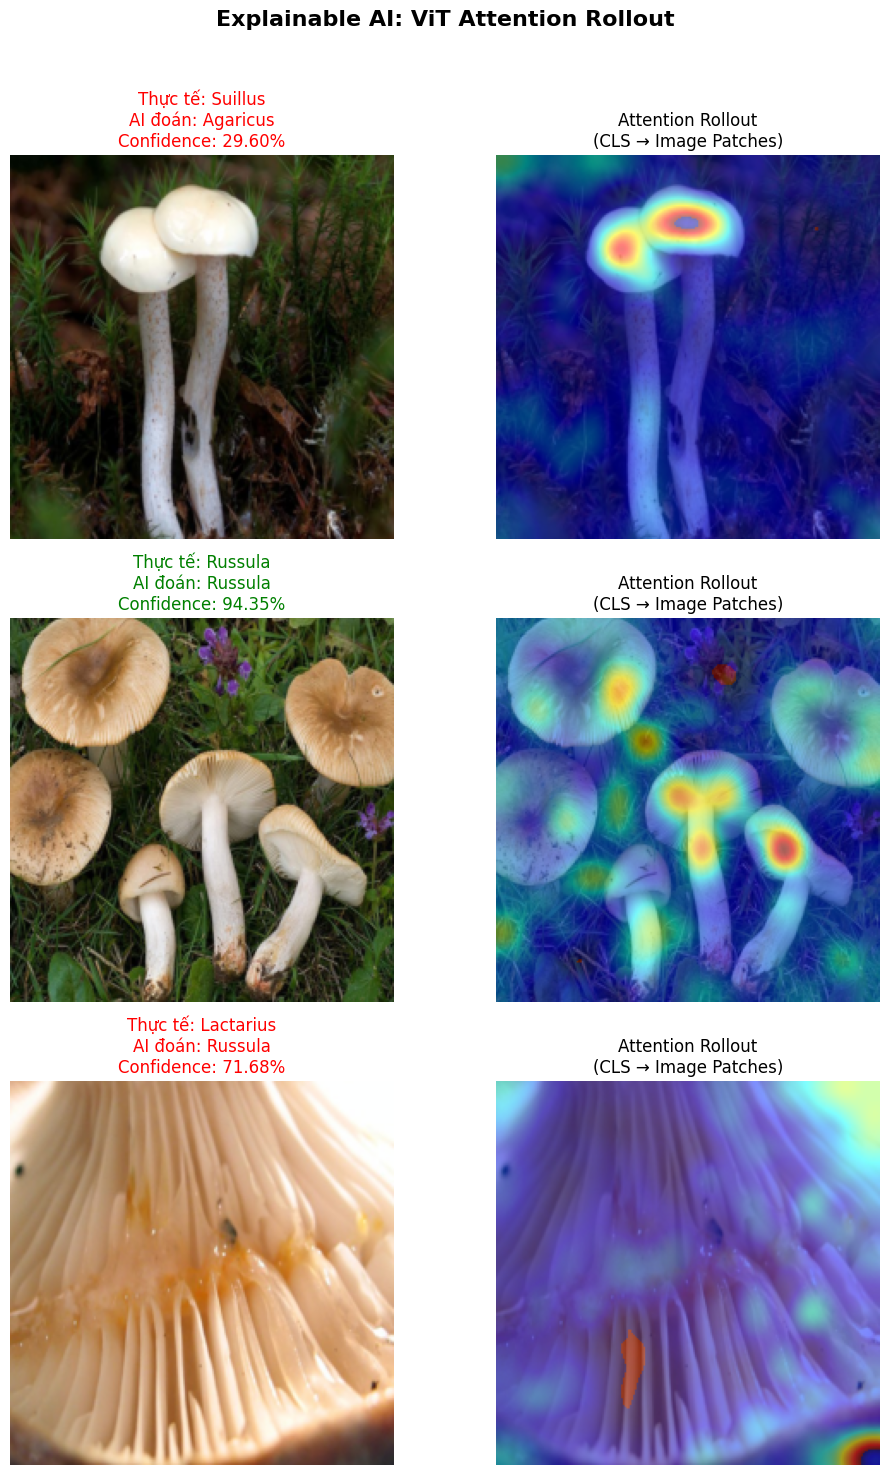


Đã xuất Attention Rollout Map:
vit_attention_rollout_maps.png


In [11]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

print("=" * 70)
print("EXPLAINABLE AI - VISION TRANSFORMER ATTENTION ROLLOUT")
print("=" * 70)


# ============================================================
# 1. KIỂM TRA MODEL
# ============================================================

best_model.eval()

print(f"Model: {best_model.__class__.__name__}")

try:
    num_layers = len(best_model.encoder.layers)
    num_heads = best_model.encoder.layers[-1].self_attention.num_heads
    embed_dim = best_model.encoder.layers[-1].self_attention.embed_dim

    print(f"Transformer layers : {num_layers}")
    print(f"Attention heads    : {num_heads}")
    print(f"Embedding dim      : {embed_dim}")

except Exception as e:
    print("Không thể đọc cấu trúc ViT:")
    print(e)


# ============================================================
# 2. HÀM LẤY ATTENTION CỦA MỘT TRANSFORMER BLOCK
# ============================================================

def get_block_attention(block, x):
    """
    Tự tính Attention Matrix của một Multi-Head Self-Attention.

    Input:
        x: [B, N, D]

    Output:
        attention: [B, H, N, N]

    Trong ViT-B/16:
        B = batch size
        H = 12 heads
        N = 197 tokens
            = 1 CLS token + 196 image patches
        D = 768
    """

    attention_layer = block.self_attention

    batch_size, seq_len, embed_dim = x.shape

    num_heads = attention_layer.num_heads
    head_dim = embed_dim // num_heads

    # --------------------------------------------------------
    # Lấy Q, K từ in_proj_weight
    # --------------------------------------------------------

    q_weight = attention_layer.in_proj_weight[
        :embed_dim
    ]

    k_weight = attention_layer.in_proj_weight[
        embed_dim:2 * embed_dim
    ]

    # --------------------------------------------------------
    # Lấy bias
    # --------------------------------------------------------

    if attention_layer.in_proj_bias is not None:

        q_bias = attention_layer.in_proj_bias[
            :embed_dim
        ]

        k_bias = attention_layer.in_proj_bias[
            embed_dim:2 * embed_dim
        ]

    else:

        q_bias = None
        k_bias = None

    # --------------------------------------------------------
    # Tính Q và K
    # --------------------------------------------------------

    q = F.linear(
        x,
        q_weight,
        q_bias
    )

    k = F.linear(
        x,
        k_weight,
        k_bias
    )

    # --------------------------------------------------------
    # Reshape Multi-Head
    #
    # [B, N, D]
    #
    # →
    #
    # [B, H, N, head_dim]
    # --------------------------------------------------------

    q = q.reshape(
        batch_size,
        seq_len,
        num_heads,
        head_dim
    )

    q = q.permute(
        0, 2, 1, 3
    )

    k = k.reshape(
        batch_size,
        seq_len,
        num_heads,
        head_dim
    )

    k = k.permute(
        0, 2, 1, 3
    )

    # --------------------------------------------------------
    # Scaled Dot-Product Attention
    #
    # Attention = softmax(QK^T / sqrt(d))
    # --------------------------------------------------------

    attention_scores = torch.matmul(
        q,
        k.transpose(-2, -1)
    )

    attention_scores = attention_scores / np.sqrt(
        head_dim
    )

    attention = torch.softmax(
        attention_scores,
        dim=-1
    )

    return attention


# ============================================================
# 3. ATTENTION ROLLOUT
# ============================================================

def get_attention_rollout(model, input_tensor):
    """
    Tính Attention Rollout qua toàn bộ Transformer layers.

    Ý tưởng:

        Layer 1
           ↓
        Layer 2
           ↓
        ...
           ↓
        Layer N

    Sau đó lấy:
        CLS → Image Patches

    Kết quả:
        Attention map 14 x 14
    """

    model.eval()

    # --------------------------------------------------------
    # ViT embedding
    # --------------------------------------------------------

    with torch.no_grad():

        # Patch embedding
        x = model.conv_proj(input_tensor)

        # [B, C, H, W]
        n, c, h, w = x.shape

        # [B, C, H*W]
        x = x.reshape(
            n,
            c,
            h * w
        )

        # [B, H*W, C]
        x = x.permute(
            0,
            2,
            1
        )

        # ----------------------------------------------------
        # CLS token
        # ----------------------------------------------------

        batch_class_token = (
            model.class_token
            .expand(
                n,
                -1,
                -1
            )
        )

        # ----------------------------------------------------
        # Thêm CLS token
        #
        # [B, 196, 768]
        #
        # →
        #
        # [B, 197, 768]
        # ----------------------------------------------------

        x = torch.cat(
            [
                batch_class_token,
                x
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Positional embedding
        # ----------------------------------------------------

        x = x + model.encoder.pos_embedding

        # ----------------------------------------------------
        # Attention Rollout matrix
        #
        # Khởi tạo Identity Matrix
        # ----------------------------------------------------

        seq_len = x.shape[1]

        rollout = torch.eye(
            seq_len,
            device=x.device
        ).unsqueeze(0)

        rollout = rollout.expand(
            n,
            -1,
            -1
        )

        # ----------------------------------------------------
        # Đi qua từng Transformer block
        # ----------------------------------------------------

        for block in model.encoder.layers:

            # -----------------------------------------------
            # torchvision ViT sử dụng LayerNorm trước
            # self-attention
            # -----------------------------------------------

            x_norm = block.ln_1(x)

            # -----------------------------------------------
            # Lấy attention
            # -----------------------------------------------

            attention = get_block_attention(
                block,
                x_norm
            )

            # -----------------------------------------------
            # Average tất cả attention heads
            #
            # [B, H, N, N]
            #
            # →
            #
            # [B, N, N]
            # -----------------------------------------------

            attention = attention.mean(
                dim=1
            )

            # -----------------------------------------------
            # Thêm residual connection
            #
            # Attention Rollout:
            #
            # A = Attention + Identity
            # -----------------------------------------------

            identity = torch.eye(
                seq_len,
                device=x.device
            ).unsqueeze(0)

            attention = attention + identity

            # Normalize từng hàng
            attention = attention / attention.sum(
                dim=-1,
                keepdim=True
            )

            # -----------------------------------------------
            # Tích lũy attention
            # -----------------------------------------------

            rollout = torch.bmm(
                attention,
                rollout
            )

            # -----------------------------------------------
            # Tính output block để tiếp tục forward
            # -----------------------------------------------

            # MultiheadAttention output
            attn_output = block.self_attention(
                x_norm,
                x_norm,
                x_norm,
                need_weights=False
            )[0]

            # Residual
            x = x + block.dropout(
                attn_output
            )

            # MLP
            x = x + block.mlp(
                block.ln_2(x)
            )

    # ========================================================
    # Lấy CLS token → 196 patches
    # ========================================================

    cls_attention = rollout[
        0,
        0,
        1:
    ]

    # ========================================================
    # Kiểm tra số patches
    # ========================================================

    num_patches = cls_attention.numel()

    grid_size = int(
        np.sqrt(num_patches)
    )

    if grid_size * grid_size != num_patches:

        raise ValueError(
            f"Không thể reshape {num_patches} patches "
            f"thành hình vuông."
        )

    # ========================================================
    # Reshape thành grid
    # ========================================================

    attention_map = cls_attention.reshape(
        grid_size,
        grid_size
    )

    attention_map = attention_map.cpu().numpy()

    # ========================================================
    # Normalize [0, 1]
    # ========================================================

    min_val = attention_map.min()
    max_val = attention_map.max()

    if max_val - min_val > 1e-8:

        attention_map = (
            attention_map - min_val
        ) / (
            max_val - min_val
        )

    else:

        attention_map = np.zeros_like(
            attention_map
        )

    return attention_map


# ============================================================
# 4. HÀM UNNORMALIZE ẢNH
# ============================================================

def unnormalize(tensor):

    img = (
        tensor
        .detach()
        .cpu()
        .numpy()
        .transpose((1, 2, 0))
    )

    mean = np.array([
        0.485,
        0.456,
        0.406
    ])

    std = np.array([
        0.229,
        0.224,
        0.225
    ])

    img = std * img + mean

    img = np.clip(
        img,
        0,
        1
    )

    return img


# ============================================================
# 5. LẤY 3 ẢNH VALIDATION
# ============================================================

best_model.eval()

inputs, labels = next(
    iter(val_loader)
)

# Chỉ lấy 3 ảnh
inputs = inputs[:3]
labels = labels[:3]

inputs = inputs.to(device)
labels = labels.to(device)


# ============================================================
# 6. PREDICTION
# ============================================================

with torch.no_grad():

    outputs = best_model(
        inputs
    )

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidence, preds = torch.max(
        probabilities,
        dim=1
    )


# ============================================================
# 7. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(10, 15)
)

fig.suptitle(
    "Explainable AI: ViT Attention Rollout",
    fontsize=16,
    fontweight='bold',
    y=0.98
)


# ============================================================
# 8. VẼ TỪNG ẢNH
# ============================================================

for i in range(3):

    # --------------------------------------------------------
    # Tensor ảnh
    # --------------------------------------------------------

    img_tensor = inputs[
        i:i + 1
    ]

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    true_index = labels[
        i
    ].item()

    pred_index = preds[
        i
    ].item()

    true_label = class_names[
        true_index
    ]

    pred_label = class_names[
        pred_index
    ]

    confidence_value = confidence[
        i
    ].item() * 100

    # --------------------------------------------------------
    # Attention Rollout
    # --------------------------------------------------------

    attn_map = get_attention_rollout(
        best_model,
        img_tensor
    )

    # --------------------------------------------------------
    # Resize 14x14 → 224x224
    # --------------------------------------------------------

    attn_map_resized = cv2.resize(
        attn_map,
        (224, 224),
        interpolation=cv2.INTER_CUBIC
    )

    # --------------------------------------------------------
    # Original image
    # --------------------------------------------------------

    original_img = unnormalize(
        inputs[i]
    )

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    heatmap = cv2.applyColorMap(
        np.uint8(
            255 * attn_map_resized
        ),
        cv2.COLORMAP_JET
    )

    heatmap = np.float32(
        heatmap
    ) / 255.0

    # BGR → RGB
    heatmap = heatmap[
        ...,
        ::-1
    ]

    # --------------------------------------------------------
    # Overlay
    # --------------------------------------------------------

    overlay = (
        0.5 * original_img
        +
        0.5 * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    # --------------------------------------------------------
    # Màu title:
    # xanh = đúng
    # đỏ = sai
    # --------------------------------------------------------

    title_color = (
        'green'
        if true_label == pred_label
        else 'red'
    )

    # ========================================================
    # CỘT 1 - ORIGINAL IMAGE
    # ========================================================

    axes[i, 0].imshow(
        original_img
    )

    axes[i, 0].set_title(
        f"Thực tế: {true_label}\n"
        f"AI đoán: {pred_label}\n"
        f"Confidence: {confidence_value:.2f}%",
        color=title_color
    )

    axes[i, 0].axis(
        'off'
    )

    # ========================================================
    # CỘT 2 - ATTENTION ROLLOUT
    # ========================================================

    axes[i, 1].imshow(
        overlay
    )

    axes[i, 1].set_title(
        "Attention Rollout\n"
        "(CLS → Image Patches)"
    )

    axes[i, 1].axis(
        'off'
    )


# ============================================================
# 9. LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


# ============================================================
# 10. SAVE
# ============================================================

output_path = (
    "vit_attention_rollout_maps.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()


print()
print("=" * 70)
print(
    f"Đã xuất Attention Rollout Map:"
)
print(
    f"{output_path}"
)
print("=" * 70)

In [12]:
torch.save(best_model.state_dict(), "vit_best_model.pth")
print("Đã lưu model: vit_best_model.pth")

Đã lưu model: vit_best_model.pth


In [13]:
best_model.load_state_dict(
    torch.load("vit_best_model.pth", map_location=device)
)
best_model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [14]:
# Lưu model
model_path = "/kaggle/working/vit_best_model.pth"

torch.save(
    best_model.state_dict(),
    model_path
)

print(f"✅ Đã lưu model tại: {model_path}")

✅ Đã lưu model tại: /kaggle/working/vit_best_model.pth


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import timm

print("🚀 BẮT ĐẦU ÉP XUNG VISION TRANSFORMER (ViT) VỚI CÔNG THỨC SOTA 🚀")

# =====================================================================
# 1. DATA AUGMENTATION (DÙNG RANDAUGMENT GIỐNG CONVNEXT)
# =====================================================================
# RandAugment là thuật toán tự động tìm ra phép biến đổi khó nhất để ép model học
train_transform_advanced = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9), # Vũ khí bí mật từ file PDF của bạn
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cập nhật lại Transform cho tập Train (nhớ gọi lại DataLoader nếu cần)
train_dataset.transform = train_transform_advanced

# =====================================================================
# 2. KHỞI TẠO LẠI MẠNG ViT BẰNG THƯ VIỆN TIMM
# =====================================================================
# Thay vì dùng torchvision, ta dùng 'timm' giống file PDF vì nó tối ưu weights tốt hơn
model_vit_advanced = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
model_vit_advanced = model_vit_advanced.to(device)

# Bỏ qua bước đóng băng (Freeze), chúng ta train thẳng toàn bộ mạng (End-to-end) 
# vì ViT cần học lại biểu diễn của nấm từ các patch.

# =====================================================================
# 3. KỸ THUẬT LOSS & OPTIMIZER HẠNG NẶNG (TỪ FILE PDF)
# =====================================================================
# Kết hợp cả Class Weights (Trị mất cân bằng) VÀ Label Smoothing (Trị tự tin thái quá)
criterion_advanced = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

# Dùng AdamW thay cho Adam (AdamW tách biệt L2 Regularization, chống Overfitting cực tốt)
optimizer_advanced = optim.AdamW(model_vit_advanced.parameters(), lr=1e-4, weight_decay=1e-2)

# Cosine Annealing Warm Restarts: Learning rate dao động hình sin, giúp thoát khỏi Local Minima
scheduler_advanced = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_advanced, T_0=5, T_mult=2, eta_min=1e-6)

# =====================================================================
# 4. TRAINING LOOP VỚI MIXED PRECISION (AMP) BẢN NÂNG CẤP
# =====================================================================
scaler = torch.amp.GradScaler('cuda')

def train_advanced(model, criterion, optimizer, scheduler, num_epochs=15):
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' - ')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss, correct, total = 0.0, 0, 0
            
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Bật Mixed Precision để train nhanh và mượt hơn
                    with torch.amp.autocast('cuda'):
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        # Gradient Clipping (Cắt gradient nếu quá lớn, tránh nổ gradient)
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            epoch_loss = running_loss / total
            epoch_acc = correct / total
            
            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}', end=' | ')
            
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), 'vit_ultimate_best.pth')
                    print("⭐ BEST! ⭐", end="")
                scheduler.step() # Lịch trình Cosine Annealing cập nhật
        print()
    return best_acc

# CHẠY THỰC NGHIỆM!
best_vit_acc = train_advanced(model_vit_advanced, criterion_advanced, optimizer_advanced, scheduler_advanced, num_epochs=15)
print(f"\n🎉 KẾT QUẢ ĐỈNH CAO MỚI CỦA ViT: {best_vit_acc:.4f}")

🚀 BẮT ĐẦU ÉP XUNG VISION TRANSFORMER (ViT) VỚI CÔNG THỨC SOTA 🚀


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/15 - TRAIN Loss: 1.3919 Acc: 0.6446 | VAL Loss: 1.1112 Acc: 0.8064 | ⭐ BEST! ⭐
Epoch 2/15 - TRAIN Loss: 0.9730 Acc: 0.8479 | VAL Loss: 1.0481 Acc: 0.8496 | ⭐ BEST! ⭐
Epoch 3/15 - TRAIN Loss: 0.8043 Acc: 0.9207 | VAL Loss: 0.9237 Acc: 0.8652 | ⭐ BEST! ⭐
Epoch 4/15 - TRAIN Loss: 0.7064 Acc: 0.9683 | VAL Loss: 0.8313 Acc: 0.9188 | ⭐ BEST! ⭐
Epoch 5/15 - TRAIN Loss: 0.6547 Acc: 0.9877 | VAL Loss: 0.7937 Acc: 0.9382 | ⭐ BEST! ⭐
Epoch 6/15 - TRAIN Loss: 0.8029 Acc: 0.9233 | VAL Loss: 1.0263 Acc: 0.8369 | 
Epoch 7/15 - TRAIN Loss: 0.8155 Acc: 0.9212 | VAL Loss: 1.0535 Acc: 0.8563 | 
Epoch 8/15 - TRAIN Loss: 0.7667 Acc: 0.9367 | VAL Loss: 0.9456 Acc: 0.8876 | 
Epoch 9/15 - TRAIN Loss: 0.7440 Acc: 0.9473 | VAL Loss: 0.9014 Acc: 0.8868 | 
Epoch 10/15 - TRAIN Loss: 0.7026 Acc: 0.9654 | VAL Loss: 0.8746 Acc: 0.9010 | 
Epoch 11/15 - TRAIN Loss: 0.6683 Acc: 0.9803 | VAL Loss: 0.8788 Acc: 0.9106 | 
Epoch 12/15 - TRAIN Loss: 0.6549 Acc: 0.9885 | VAL Loss: 0.8478 Acc: 0.9226 | 
Epoch 13/15 - TR